Import all required libraries and load the raw car evaluation dataset. The features are kept as strings at this stage because the pipeline will handle the ordinal encoding later.

In [1]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv('dataset/cars_classification_dataset.csv')
df.head()

,buying,maint,doors,persons,lug_boot,safety,car
0,vhigh,vhigh,two,two,small,low,unacc
1,vhigh,vhigh,two,two,small,med,unacc
2,vhigh,vhigh,two,two,small,high,unacc
3,vhigh,vhigh,two,two,med,low,unacc
4,vhigh,vhigh,two,two,med,med,unacc


Split the raw data into train and test sets using stratified sampling to preserve the class proportions in both splits. Then build a pipeline that ordinal-encodes the six categorical features in their natural order, applies SMOTE only on the training data, and trains a Decision Tree classifier limited to max_depth=5 to prevent overfitting. The encoder is required here because SMOTE needs numeric input, even though the tree itself does not care about encoding. The pipeline is fit on the training set and predictions are made on the untouched test set, so SMOTE never touches the test data.

In [ ]:
X = df.drop(columns=['car'])
y = df['car']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

categories = [
    ['low', 'med', 'high', 'vhigh'],      # buying
    ['low', 'med', 'high', 'vhigh'],      # maint
    ['two', 'three', 'four', '5more'],    # doors
    ['two', 'four', 'more'],              # persons
    ['small', 'med', 'big'],              # lug_boot
    ['low', 'med', 'high'],               # safety
]

pipeline = Pipeline(steps=[
    ('encoder', OrdinalEncoder(categories=categories)),
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

Evaluate the trained model on the original test set. Print the overall accuracy and a confusion matrix with a fixed class order from worst to best acceptability, then display the same matrix visually for easier inspection of per-class errors.

Accuracy: 0.8468
Confusion matrix:
[[201  40   1   0]
 [  0  67   8   2]
 [  0   0  12   2]
 [  0   0   0  13]]


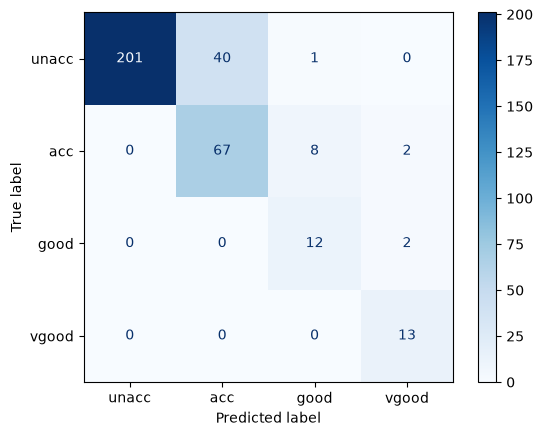

In [3]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred, labels=['unacc', 'acc', 'good', 'vgood'])
print("Confusion matrix:")
print(cm)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=['unacc', 'acc', 'good', 'vgood'],
    cmap='Blues'
)
plt.show()

Persist the entire trained pipeline to disk with joblib so it can be reloaded later for computing additional metrics without retraining. Saving the pipeline (not just the classifier) means the encoder and its learned mappings travel with the model.

In [ ]:
import joblib

joblib.dump(pipeline, 'dec_tree_model.joblib')